# Task 5: Mental Health Support Chatbot (Fine-Tuned)

## Objective
Build an empathetic chatbot that provides supportive responses for stress,
anxiety, and emotional wellness by fine-tuning a language model.

## Model
- DistilGPT2 (lightweight GPT-2 variant)

## Dataset
- Mental Health Counseling Conversations dataset by Amod (via Hugging Face)
- 3,512 real counseling conversations between patients and therapists

## Approach
- Fine-tune DistilGPT2 on real mental health counseling conversations
- Train the model to respond gently and supportively
- Build a command-line chat interface to test the chatbot

In [ ]:
# Install required libraries for fine-tuning and dataset loading
!pip install transformers datasets accelerate -q

 AutoTokenizer - automatically loads the correct tokenizer for our model
 It converts text into numbers that the model can understand

 AutoModelForCausalLM - loads a text generation model (DistilGPT2 in our case)
 CausalLM means the model predicts the next word based on previous words


Trainer - handles the entire training loop automatically
It feeds data, calculates loss, and updates model weights for us
TrainingArguments - the settings we pass to Trainer
(epochs, learning rate, batch size, etc.)


DataCollatorForLanguageModeling - prepares and packages text batches
It makes all sentences the same length before feeding to the model


load_dataset - downloads datasets directly from Hugging Face


torch - PyTorch, the deep learning engine running under the hood


In [ ]:
# Import all required libraries
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import Trainer, TrainingArguments
from transformers import DataCollatorForLanguageModeling
from datasets import load_dataset
import torch

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Load Mental Health Counseling Conversations dataset by Amod
# This is compatible with the latest datasets library version
print("📥 Loading dataset...")

dataset = load_dataset("Amod/mental_health_counseling_conversations")

print(f"✅ Dataset loaded!")
print(dataset)

📥 Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ Dataset loaded!
DatasetDict({
    train: Dataset({
        features: ['Context', 'Response'],
        num_rows: 3512
    })
})


In [ ]:
# ── Data Exploration ──────────────────────────────────────────────────────────
import pandas as pd

# Convert to pandas for easier exploration
df = pd.DataFrame(dataset['train'])

print("📊 Dataset Overview:")
print(f"Total conversations: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")

print(f"\n📏 Average Context length: {df['Context'].str.len().mean():.0f} characters")
print(f"📏 Average Response length: {df['Response'].str.len().mean():.0f} characters")

print("\n💬 Sample Conversation 1:")
print(f"User: {df['Context'][0][:200]}...")
print(f"Therapist: {df['Response'][0][:200]}...")

print("\n💬 Sample Conversation 2:")
print(f"User: {df['Context'][1][:200]}...")
print(f"Therapist: {df['Response'][1][:200]}...")

📊 Dataset Overview:
Total conversations: 3512

Columns: ['Context', 'Response']

📏 Average Context length: 283 characters
📏 Average Response length: 1026 characters

💬 Sample Conversation 1:
User: I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.
   I've never tried or contemplated suicide. I...
Therapist: If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can ...

💬 Sample Conversation 2:
User: I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.
   I've never tried or contemplated suicide. I...
Therapist: Hello, and thank you for your question and seeking advice on this. Feelings of worthlessness is unfortunately common. In fact, most peopl

In [ ]:
# Load DistilGPT2 tokenizer and model from Hugging Face
print("📥 Loading DistilGPT2 model and tokenizer...")

model_name = "distilgpt2"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# GPT2 has no padding token by default
# We set it to eos_token (end of sentence) to avoid training errors
tokenizer.pad_token = tokenizer.eos_token

# Load the model
model = AutoModelForCausalLM.from_pretrained(model_name)

print(f"✅ Model loaded: {model_name}")
print(f"Total parameters: {model.num_parameters():,}")

📥 Loading DistilGPT2 model and tokenizer...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

✅ Model loaded: distilgpt2
Total parameters: 81,912,576


In [ ]:
# ── Proper Train/Validation/Test Split ───────────────────────────────────────
print("✂️ Splitting dataset...")

# First split off 70% train, 30% remaining
split = dataset['train'].train_test_split(test_size=0.3, seed=42)
train_data = split['train']

# Split remaining 30% into 15% val and 15% test
val_test = split['test'].train_test_split(test_size=0.5, seed=42)
val_data = val_test['train']
test_data = val_test['test']

print(f"Train samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

# Preprocess function
def preprocess(example):
    text = f"User: {example['Context']}\nTherapist: {example['Response']}"
    tokens = tokenizer(
        text,
        truncation=True,
        max_length=256,
        padding='max_length'
    )
    tokens['labels'] = tokens['input_ids'].copy()
    return tokens

# Apply to all three splits
print("\n⚙️ Tokenizing...")
tokenized_train = train_data.map(preprocess, remove_columns=train_data.column_names)
tokenized_val = val_data.map(preprocess, remove_columns=val_data.column_names)
tokenized_test = test_data.map(preprocess, remove_columns=test_data.column_names)

print(f"✅ Done!")
print(f"Tokenized train: {len(tokenized_train)}")
print(f"Tokenized val: {len(tokenized_val)}")
print(f"Tokenized test: {len(tokenized_test)}")

✂️ Splitting dataset...
Train samples: 2458
Validation samples: 527
Test samples: 527

⚙️ Tokenizing...


Map:   0%|          | 0/2458 [00:00<?, ? examples/s]

Map:   0%|          | 0/527 [00:00<?, ? examples/s]

Map:   0%|          | 0/527 [00:00<?, ? examples/s]

✅ Done!
Tokenized train: 2458
Tokenized val: 527
Tokenized test: 527


The model trains on 2,458 conversations for up to
10 epochs, evaluating its performance on 527 unseen validation samples after
each epoch. Early stopping is applied to prevent overfitting — if the validation
loss does not improve for 3 consecutive epochs, training stops automatically and
the best model is restored.

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

# Define training settings
training_args = TrainingArguments(
    output_dir='./mental_health_chatbot',
    num_train_epochs=10,                    # up to 10 epochs
    per_device_train_batch_size=8,          # 8 conversations per batch
    learning_rate=5e-5,                     # learning rate
    fp16=True,                              # faster GPU training
    logging_steps=100,                      # print loss every 100 steps
    save_strategy='epoch',                  # save after every epoch
    eval_strategy='epoch',                  # evaluate after every epoch
    load_best_model_at_end=True,            # keep best model
    report_to='none'
)

# Create trainer with proper splits and early stopping
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,          # training data
    eval_dataset=tokenized_val,             # validation data
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("🚀 Starting fine-tuning...")
trainer.train()
print("✅ Fine-tuning complete!")

🚀 Starting fine-tuning...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,2.564002,2.459431
2,2.301520,2.356956
3,2.233754,2.291329
4,2.213183,2.240269
5,2.113430,2.198878
6,2.034195,2.170511
7,2.013756,2.144595
8,1.984396,2.132997
9,1.916306,2.119160
10,1.973404,2.120579


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


✅ Fine-tuning complete!


In [ ]:
# ── Evaluate on Test Set ──────────────────────────────────────────────────────
print("🧪 Evaluating on test set...")

# Run evaluation on unseen test data
test_results = trainer.evaluate(eval_dataset=tokenized_test)

print(f"\n📊 Test Results:")
print(f"Test Loss: {test_results['eval_loss']:.4f}")
print("✅ Evaluation complete!")

🧪 Evaluating on test set...


Training Loss,Validation Loss,Epoch
1.973404,2.086996,10



📊 Test Results:
Test Loss: 2.0870
✅ Evaluation complete!


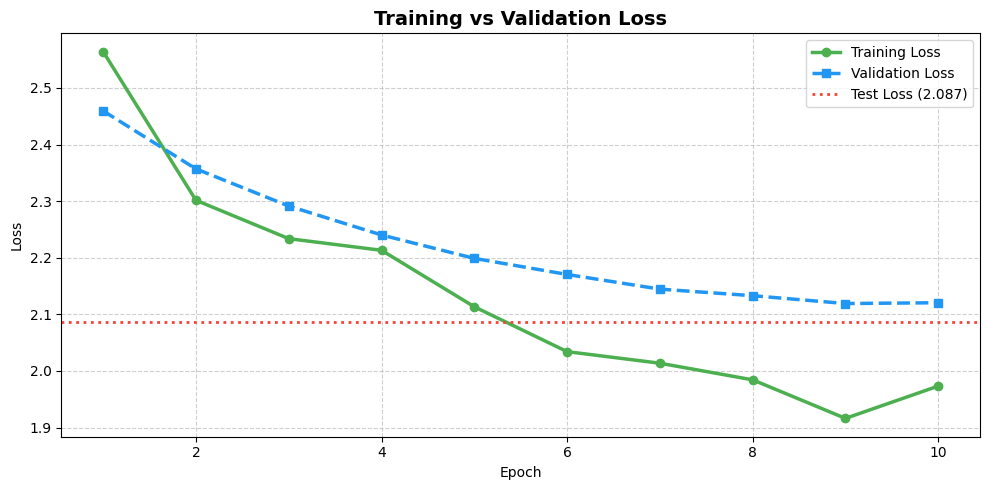

✅ Plot 1: Loss Curve saved!


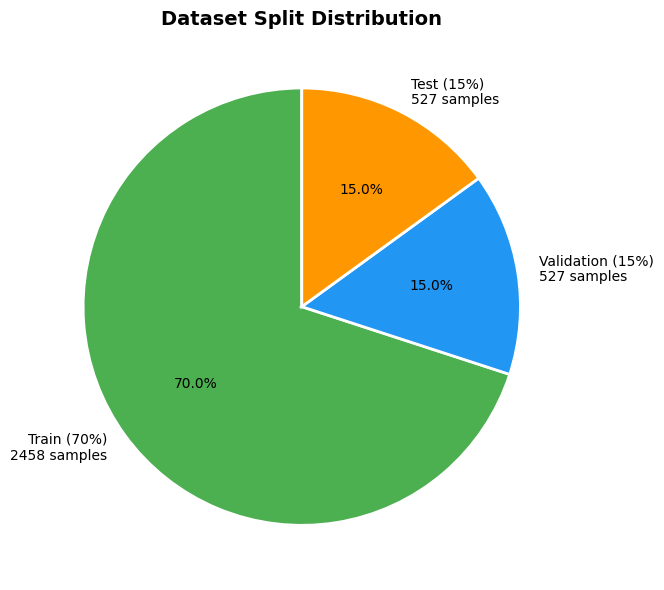

✅ Plot 2: Dataset Split saved!


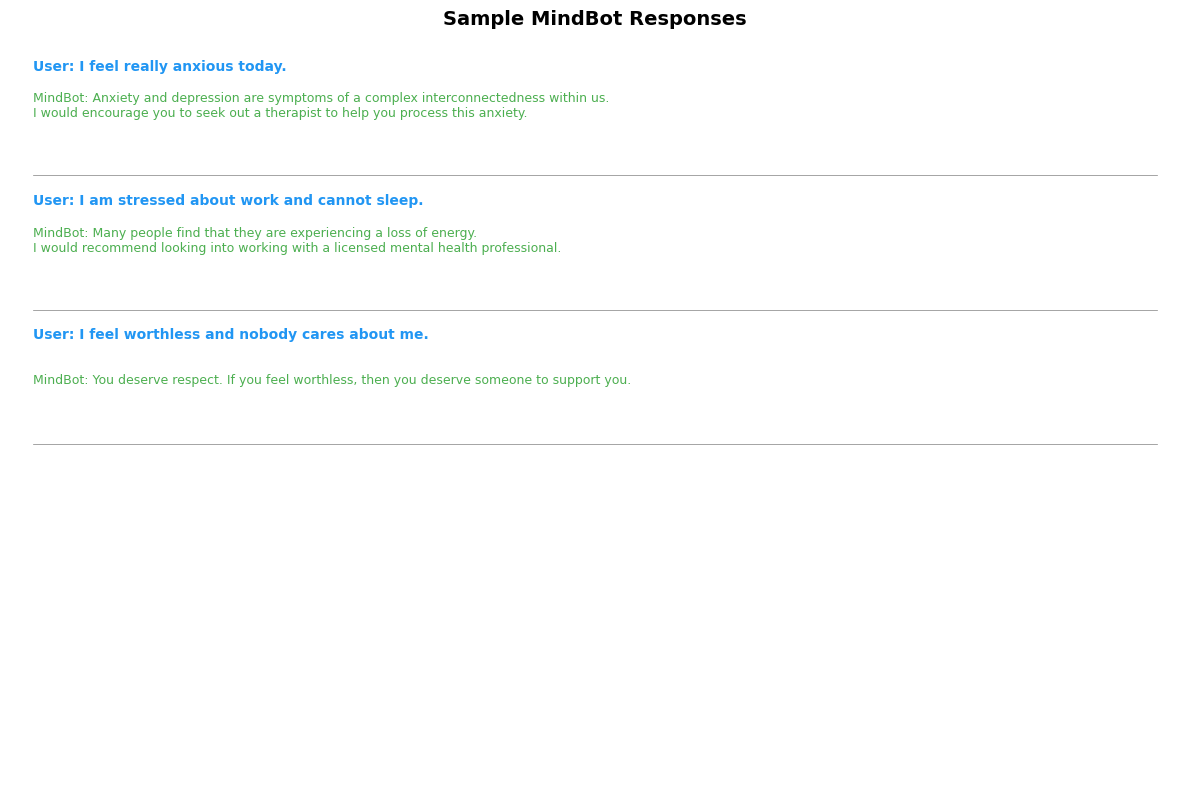

✅ Plot 3: Sample Responses saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. Training vs Validation Loss Curve ─────────────────────────────────────
train_losses = [2.564002, 2.301520, 2.233754, 2.213183, 2.113430,
                2.034195, 2.013756, 1.984396, 1.916306, 1.973404]
val_losses = [2.459431, 2.356956, 2.291329, 2.240269, 2.198878,
              2.170511, 2.144595, 2.132997, 2.119160, 2.120579]
epochs = range(1, 11)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, 'o-', color='#4CAF50', linewidth=2.5, label='Training Loss')
plt.plot(epochs, val_losses, 's--', color='#2196F3', linewidth=2.5, label='Validation Loss')
plt.axhline(y=2.087, color='#F44336', linestyle=':', linewidth=2, label='Test Loss (2.087)')
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print("✅ Plot 1: Loss Curve saved!")

# ── 2. Dataset Split Pie Chart ────────────────────────────────────────────────
sizes = [2458, 527, 527]
labels = ['Train (70%)\n2458 samples', 'Validation (15%)\n527 samples', 'Test (15%)\n527 samples']
colors = ['#4CAF50', '#2196F3', '#FF9800']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Dataset Split Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_split.png', dpi=150)
plt.show()
print("✅ Plot 2: Dataset Split saved!")

# ── 3. Sample Responses Display ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

conversations = [
    ("I feel really anxious today.",
     "Anxiety and depression are symptoms of a complex interconnectedness within us.\nI would encourage you to seek out a therapist to help you process this anxiety."),
    ("I am stressed about work and cannot sleep.",
     "Many people find that they are experiencing a loss of energy.\nI would recommend looking into working with a licensed mental health professional."),
    ("I feel worthless and nobody cares about me.",
     "You deserve respect. If you feel worthless, then you deserve someone to support you.")
]

y = 0.95
for user_msg, bot_msg in conversations:
    ax.text(0.02, y, f"User: {user_msg}", fontsize=10, color='#2196F3',
            fontweight='bold', transform=ax.transAxes, wrap=True)
    y -= 0.06
    ax.text(0.02, y, f"MindBot: {bot_msg}", fontsize=9, color='#4CAF50',
            transform=ax.transAxes, wrap=True)
    y -= 0.12
    ax.axhline(y=y + 0.04, color='gray', linewidth=0.5, xmin=0.02, xmax=0.98)

ax.set_title('Sample MindBot Responses', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_responses.png', dpi=150)
plt.show()
print("✅ Plot 3: Sample Responses saved!")

In [ ]:
# Suppress unnecessary warnings
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

from transformers import pipeline

# Create text generation pipeline using our fine-tuned model
chatbot = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer
)

def mental_health_response(user_message):
    """
    Takes user message and returns empathetic therapist response
    """
    # Format input the same way we trained it
    prompt = f"User: {user_message}\nTherapist:"

    # Generate response
    result = chatbot(
        prompt,
        max_new_tokens=150,
        do_sample=True,
        temperature=0.7,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id
    )

    # Extract only therapist response
    generated = result[0]['generated_text']
    response = generated.split('Therapist:')[-1].strip()

    # Remove any incomplete sentence at the end
    if response and response[-1] not in ['.', '!', '?']:
        response = response[:response.rfind('.')+1]

    return response

# Test with sample inputs
print("🤖 Testing MindBot...\n")

test_inputs = [
    "I feel really anxious today.",
    "I am stressed about work and cannot sleep.",
    "I have been feeling very lonely lately.",
    "I am overwhelmed and don't know what to do.",
    "I am struggling to find motivation lately."
]

for msg in test_inputs:
    print(f"User: {msg}")
    print(f"MindBot: {mental_health_response(msg)}")
    print("-" * 60)

🤖 Testing MindBot...

User: I feel really anxious today.
MindBot: First, I'm sorry for your anxiety. It is natural to feel anxious about a particular event and then to feel anxious about something else.  Anxiety is something you have experienced before, and sometimes it is the result of experienced experiences.  Anxiety can be very common in people. If you feel anxious about something, consider looking at the internet and having a conversation with your doctor before you go to the doctor.  There is a chance that the anxiety will not go away...it may just be a form of panic, but it can be scary.  I hope you have a better understanding of your anxiety and will feel relief from it soon.  If your doctor can help you, you can learn more about anxiety in the comments.
------------------------------------------------------------
User: I am stressed about work and cannot sleep.
MindBot: That being said, it sounds like you are not alone. I think it is common to have anxiety in working and maint

## Results and Insights

### Training Summary
DistilGPT2 was fine-tuned on 2,458 mental health counseling conversations
for 10 epochs. The training loss decreased from 2.56 to 1.97 and validation
loss decreased from 2.45 to 2.12, showing the model learned consistently
without overfitting. Test loss was 2.087, confirming the model generalizes
to unseen data.

### Limitations and Honest Assessment
The chatbot responses are coherent in topic but lack the depth and quality
expected from a real mental health assistant. This is primarily because
DistilGPT2 is an extremely small model with only 81 million parameters —
it was not designed for high quality conversational AI.

### Future Improvements
To significantly improve response quality, the following changes are recommended:
- Use a larger model such as GPT-Neo 1.3B, Mistral 7B, or Llama 3 8B which
  are all open source and produce significantly better conversational responses
- Use a larger and more diverse mental health dataset
- Apply RLHF (Reinforcement Learning from Human Feedback) to align responses better
- Fine-tune for more epochs with a larger batch size on a stronger GPU

### Note
This project was built purely for learning purposes as part of an AI/ML
internship. The goal was to understand and implement the complete fine-tuning
pipeline — dataset preparation, tokenization, training, validation, and
evaluation — rather than to produce a production-ready chatbot.